In [24]:
# GDELT API v2 - Download articoli per asset su finestre settimanali
import time
import json
import random
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import requests

# =========================
BASE_URL = "https://api.gdeltproject.org/api/v2/doc/doc"

ASSET_QUERIES = {
    "BTC": 'bitcoin AND (crypto OR cryptocurrency OR blockchain)',
    "ETH": 'ethereum AND (crypto OR cryptocurrency OR blockchain)',
    "SOL": 'solana AND (crypto OR cryptocurrency OR blockchain)',
    "XRP": 'ripple AND (crypto OR cryptocurrency OR blockchain)',
    "BNB": 'binance AND (crypto OR cryptocurrency OR blockchain)',
}

OUT_HOURLY = "gdelt_hourly_2Y_top5.csv"
OUT_LOGS   = "gdelt_logs_2Y_top5.csv"

# Rate limit: ~1 request ogni >5s
SLEEP_SEC = 6.2
TIMEOUT   = 30
RETRIES   = 10
# Tone cleaning
TONE_ABS_MAX = 50
TONE_WHEN_NO_NEWS = 0.0
INCLUDE_NEWS_SHARE = True
#session
SESSION = requests.Session()


In [25]:
# Helper date + finestre settimanali per mantenere granularità oraria
def to_gdelt_dt(dt: datetime) -> str:
    """GDELT wants YYYYMMDDHHMMSS in UTC."""
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    dt = dt.astimezone(timezone.utc)
    return dt.strftime("%Y%m%d%H%M%S")


def weekly_windows(start_dt: datetime, end_dt: datetime):
    """Finestre [start, end) di 7 giorni per preservare risoluzione oraria."""
    if start_dt.tzinfo is None:
        start_dt = start_dt.replace(tzinfo=timezone.utc)
    if end_dt.tzinfo is None:
        end_dt = end_dt.replace(tzinfo=timezone.utc)

    cur = start_dt
    while cur < end_dt:
        nxt = min(cur + timedelta(days=7), end_dt)
        yield cur, nxt
        cur = nxt


In [26]:
#safe_get (rate limit + retry + JSON robusto)
def safe_get(params, timeout=TIMEOUT, retries=RETRIES, base_sleep=SLEEP_SEC):
    """
    Robust request:
    - throttling base tra chiamate (>=5s) + jitter
    - 429 backoff
    - gestisce non-JSON (HTML) e JSON rotto/troncato
    """
    last_err = None

    for attempt in range(1, retries + 1):
        # throttling
        if attempt == 1:
            time.sleep(base_sleep + random.random() * 0.4)
        else:
            time.sleep(base_sleep + min(30, attempt * 2) + random.random() * 0.6)

        try:
            resp = requests.get(
                BASE_URL,
                params=params,
                timeout=timeout,
                headers={"Connection": "close"}
            )

            ct = (resp.headers.get("Content-Type") or "").lower()
            body_snip = resp.text[:300].replace("\n", " ")

            # 429 rate limit
            if resp.status_code == 429:
                wait = min(180, 10 + attempt * 12)
                print(f"[GDELT] 429 rate limit | attempt={attempt} | wait~{wait}s")
                time.sleep(wait)
                last_err = RuntimeError("HTTP 429")
                continue


            if resp.status_code >= 500:
                wait = min(120, 5 + attempt * 6)
                print(f"[GDELT] {resp.status_code} server error | attempt={attempt} | wait~{wait}s | CT={ct}")
                time.sleep(wait)
                last_err = RuntimeError(f"HTTP {resp.status_code}")
                continue

            resp.raise_for_status()

            # non-JSON response
            if "application/json" not in ct:
                wait = min(90, 5 + attempt * 6)
                print(f"[GDELT] non-JSON response | attempt={attempt} | wait~{wait}s | CT={ct} | body={body_snip}")
                time.sleep(wait)
                last_err = RuntimeError("Non-JSON response")
                continue

            # parse JSON
            try:
                data = resp.json()
            except json.JSONDecodeError as e:
                wait = min(90, 5 + attempt * 6)
                print(f"[GDELT] JSON decode failed | attempt={attempt} | wait~{wait}s | err={e} | body={body_snip}")
                time.sleep(wait)
                last_err = e
                continue

            return data, resp.url

        except requests.RequestException as e:
            wait = min(90, 3 + attempt * 6)
            print(f"[GDELT] request exception | attempt={attempt} | wait~{wait}s | err={e}")
            time.sleep(wait)
            last_err = e

    raise RuntimeError(f"GDELT request failed after {retries} retries: {last_err}")


In [27]:
def extract_timeline_points(j: dict):
    if not isinstance(j, dict):
        return []
    tl = j.get("timeline")
    if tl is None:
        return []
    if isinstance(tl, list) and tl:
        tl = tl[0]
    if isinstance(tl, dict):
        data = tl.get("data", [])
        return data if isinstance(data, list) else []
    return []


def points_to_df(points, mode: str):
    rows = []
    for p in points:
        if not isinstance(p, dict):
            continue
        dt = p.get("date") or p.get("datetime")
        if not dt:
            continue
        ts = pd.to_datetime(dt, utc=True, errors="coerce")
        if pd.isna(ts):
            continue
        rows.append({"ts_utc": ts, "value": p.get("value", None), "mode": mode})

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("ts_utc").reset_index(drop=True)
    return df


In [28]:
#Wrapper chiamata GDELT timeline
def gdelt_timeline_df(mode: str, query: str, start_dt: datetime, end_dt: datetime):
    params = {
        "query": query,
        "mode": mode,  # timelinevolraw, timelinetone, timelinevol
        "format": "json",
        "startdatetime": to_gdelt_dt(start_dt),
        "enddatetime": to_gdelt_dt(end_dt),
        "timelinesmooth": 0,
    }
    j, url = safe_get(params)
    qd = j.get("query_details", {}) if isinstance(j, dict) else {}
    points = extract_timeline_points(j)
    df = points_to_df(points, mode)
    return df, qd, url


In [29]:
#Fetch 1 asset
def fetch_asset_hourly(asset: str, query: str, start_dt: datetime, end_dt: datetime, include_share: bool = True):
    frames = []
    logs = []

    for ws, we in weekly_windows(start_dt, end_dt):
        df_v, qd_v, url_v = gdelt_timeline_df("timelinevolraw", query, ws, we)
        df_t, qd_t, url_t = gdelt_timeline_df("timelinetone", query, ws, we)

        df_s, qd_s, url_s = None, {}, None
        if include_share:
            df_s, qd_s, url_s = gdelt_timeline_df("timelinevol", query, ws, we)

        res = (qd_v.get("date_resolution") or qd_t.get("date_resolution") or qd_s.get("date_resolution"))

        v = df_v[["ts_utc", "value"]].rename(columns={"value": "news_count_hour"}) if not df_v.empty else pd.DataFrame(columns=["ts_utc", "news_count_hour"])
        t = df_t[["ts_utc", "value"]].rename(columns={"value": "avg_tone_hour"})  if not df_t.empty else pd.DataFrame(columns=["ts_utc", "avg_tone_hour"])

        merged = pd.merge(v, t, on="ts_utc", how="outer")

        if include_share:
            s = df_s[["ts_utc", "value"]].rename(columns={"value": "news_share_hour"}) if (df_s is not None and not df_s.empty) else pd.DataFrame(columns=["ts_utc", "news_share_hour"])
            merged = pd.merge(merged, s, on="ts_utc", how="outer")

        merged = merged.rename(columns={"ts_utc": "ts_hour_utc"})
        merged["ts_hour_utc"] = pd.to_datetime(merged["ts_hour_utc"], utc=True, errors="coerce").dt.floor("h")
        merged["asset"] = asset

        # numeric
        merged["news_count_hour"] = pd.to_numeric(merged["news_count_hour"], errors="coerce").fillna(0)
        merged["avg_tone_hour"]  = pd.to_numeric(merged["avg_tone_hour"], errors="coerce")
        if include_share and "news_share_hour" in merged.columns:
            merged["news_share_hour"] = pd.to_numeric(merged["news_share_hour"], errors="coerce")

        # fix tone
        merged.loc[merged["avg_tone_hour"].abs() > TONE_ABS_MAX, "avg_tone_hour"] = np.nan
        merged.loc[merged["news_count_hour"] == 0, "avg_tone_hour"] = TONE_WHEN_NO_NEWS

        # dedup
        merged = (
            merged.dropna(subset=["ts_hour_utc"])
                  .sort_values("ts_hour_utc")
                  .drop_duplicates(["asset", "ts_hour_utc"], keep="last")
                  .reset_index(drop=True)
        )

        frames.append(merged)
        logs.append({
            "asset": asset,
            "window_start": ws,
            "window_end": we,
            "date_resolution": res,
            "url_volraw": url_v,
            "url_tone": url_t,
            "url_share": url_s,
            "rows_chunk": int(len(merged)),
        })

    df_asset = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    df_asset = (
        df_asset.dropna(subset=["asset", "ts_hour_utc"])
                .sort_values(["asset", "ts_hour_utc"])
                .drop_duplicates(["asset", "ts_hour_utc"], keep="last")
                .reset_index(drop=True)
    )

    log_asset = pd.DataFrame(logs)
    return df_asset, log_asset


In [30]:
#Fetch multi-asset + salvataggio CSV
def fetch_multi_asset(asset_queries: dict, start_dt: datetime, end_dt: datetime):
    all_frames = []
    all_logs = []

    for asset, q in asset_queries.items():
        print(f"\n=== FETCH {asset} ===")
        df_a, log_a = fetch_asset_hourly(
            asset=asset,
            query=q,
            start_dt=start_dt,
            end_dt=end_dt,
            include_share=INCLUDE_NEWS_SHARE
        )
        print(f"[DONE] {asset} | rows={len(df_a)} | windows={len(log_a)}")
        all_frames.append(df_a)
        all_logs.append(log_a)

    df_all = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()
    logs_all = pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()

    if not df_all.empty:
        df_all["ts_hour_utc"] = pd.to_datetime(df_all["ts_hour_utc"], utc=True).dt.floor("h")
        df_all = (
            df_all.dropna(subset=["asset", "ts_hour_utc"])
                  .sort_values(["asset", "ts_hour_utc"])
                  .drop_duplicates(["asset", "ts_hour_utc"], keep="last")
                  .reset_index(drop=True)
        )

    df_all.to_csv(OUT_HOURLY, index=False)
    logs_all.to_csv(OUT_LOGS, index=False)
    print("\nSaved:", OUT_HOURLY, "and", OUT_LOGS)

    return df_all, logs_all


In [31]:
#run
now = datetime(2026, 1, 24, 0, 0, 0, tzinfo=timezone.utc)
start = now - timedelta(days=730)

df_all, logs_all = fetch_multi_asset(ASSET_QUERIES, start, now)
df_all.head()



=== FETCH BTC ===
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=2 | wait~34s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=2 | wait~34s
[GDELT] 429 rate limit | attempt=1 | wait~22s
[GDELT] 429 rate limit | attempt=2 | wait~34s
[GDELT] 429 rat

,ts_hour_utc,news_count_hour,avg_tone_hour,news_share_hour,asset
0,2024-01-25 00:00:00+00:00,2,-2.8011,0.0162,BNB
1,2024-01-25 01:00:00+00:00,3,-2.6148,0.0284,BNB
2,2024-01-25 02:00:00+00:00,3,-1.4714,0.0253,BNB
3,2024-01-25 03:00:00+00:00,10,-1.4407,0.0820,BNB
4,2024-01-25 04:00:00+00:00,1,-1.5385,0.0135,BNB



=== GDELT COVERAGE SUMMARY (2Y file range) ===
asset  expected_hours  present_hours  missing_hours  coverage
  BNB           17520          16981            539  0.969235
  BTC           17520          16981            539  0.969235
  ETH           17520          16981            539  0.969235
  SOL           17520          16981            539  0.969235
  XRP           17520          16981            539  0.969235

Missing hours identical across all assets: True


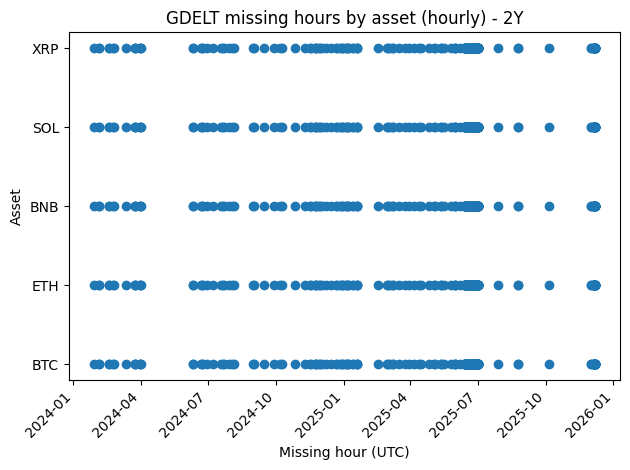


Saved figure: gdelt_missing_hours_scatter_2Y.png


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

GDELT_HOURLY_FILE = "gdelt_hourly_2Y_top5.csv"
ASSETS = ["BTC", "ETH", "BNB", "SOL", "XRP"]

df = pd.read_csv(GDELT_HOURLY_FILE)

# --- Standardize keys ---
df["asset"] = df["asset"].astype(str)
df["ts_hour_utc"] = pd.to_datetime(df["ts_hour_utc"], utc=True, errors="coerce").dt.floor("h")
df = df[df["asset"].isin(ASSETS)].dropna(subset=["asset", "ts_hour_utc"]).copy()

# --- Expected hourly grid over the file range ---
start = df["ts_hour_utc"].min()
end_excl = df["ts_hour_utc"].max() + timedelta(hours=1)  # end esclusivo
expected = pd.date_range(start=start, end=end_excl - timedelta(hours=1), freq="h", tz="UTC")
expected_n = len(expected)

# --- Missing hours per asset + summary ---
missing_map = {}
summary_rows = []

for a in ASSETS:
    present = pd.Index(df.loc[df["asset"] == a, "ts_hour_utc"].unique())
    missing = pd.Index(expected).difference(present).sort_values()
    missing_map[a] = missing

    summary_rows.append({
        "asset": a,
        "expected_hours": int(expected_n),
        "present_hours": int(len(present)),
        "missing_hours": int(len(missing)),
        "coverage": float(len(present) / expected_n) if expected_n else None
    })

summary = pd.DataFrame(summary_rows).sort_values("asset").reset_index(drop=True)
print("\n=== GDELT COVERAGE SUMMARY (2Y file range) ===")
print(summary.to_string(index=False))

# --- Check: missing hours identical across assets? ---
base = set(missing_map[ASSETS[0]].to_pydatetime())
all_equal = True
for a in ASSETS[1:]:
    if set(missing_map[a].to_pydatetime()) != base:
        all_equal = False
        break
print("\nMissing hours identical across all assets:", all_equal)

# --- Build scatter points ---
x, y = [], []
for i, a in enumerate(ASSETS):
    for ts in missing_map[a]:
        x.append(ts)
        y.append(i)

# --- Plot ---
plt.figure()
plt.scatter(x, y)
plt.yticks(range(len(ASSETS)), ASSETS)
plt.xlabel("Missing hour (UTC)")
plt.ylabel("Asset")
plt.title("GDELT missing hours by asset (hourly) - 2Y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("gdelt_missing_hours_scatter_2Y.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved figure: gdelt_missing_hours_scatter_2Y.png")
